In [69]:
import pyqtgraph as pg
import numpy as np
from scipy.signal import butter, lfilter, resample, resample_poly
import matplotlib.pyplot as plt
from scipy import signal as dsp

In [70]:

archivo = np.load('muestras_iq_20260518_154112.npz')

cf=archivo['center_freq']
sr=archivo['sample_rate']
muestras_iq = archivo['raw_iq']
print(f"Archivo cargado:{archivo}")
print(f"Muestras totales: {len(muestras_iq)}")
print("Frecuencia central:",cf/1e6,"MHz")
print("Sample rate:",sr/1e6,"MHz")

Archivo cargado:NpzFile 'muestras_iq_20260518_154112.npz' with keys: raw_iq, center_freq, sample_rate
Muestras totales: 29491200
Frecuencia central: 100.0 MHz
Sample rate: 10.0 MHz


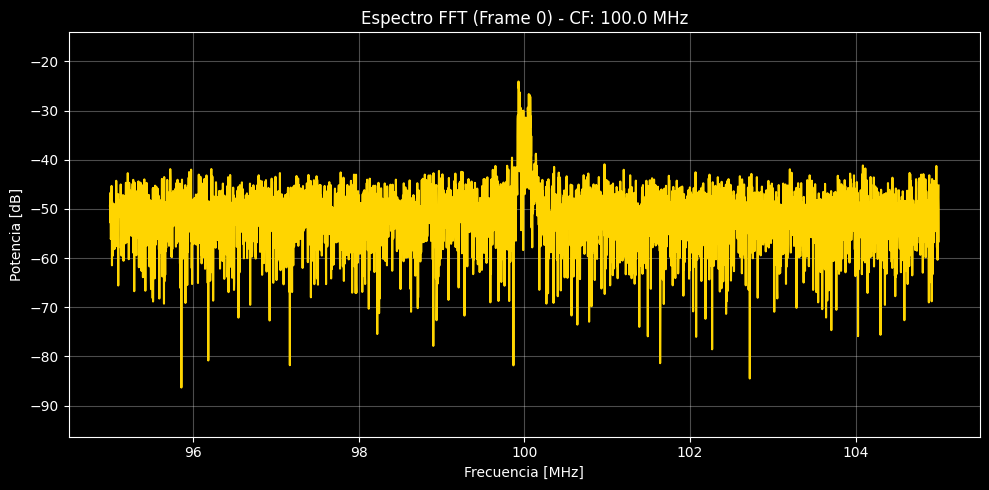

In [71]:
def plot_fft(raw_iq, cf, sr, fft_size=4096, frame_index=0):
    # 1. Calcular el inicio y fin del bloque de datos
    inicio = frame_index * fft_size
    fin = inicio + fft_size
    
    if fin > len(raw_iq):
        print(f"Error: No hay suficientes muestras para el frame {frame_index}.")
        print(f"Muestras disponibles: {len(raw_iq)}. Requeridas: {fin}")
        return
        
    # Extraer el bloque (chunk) de muestras
    chunk = raw_iq[inicio:fin].copy()
    
    # Quitar el valor medio (DC)
    chunk = chunk - np.mean(chunk)
    
    # Calcular la FFT, centrarla y calcular la potencia
    potencia = np.abs(np.fft.fftshift(np.fft.fft(chunk)))**2 / fft_size
    
    # Pasar a dB (PSD) limitando el mínimo a 1e-12 para evitar log(0)
    PSD = 10.0 * np.log10(np.maximum(potencia, 1e-12))
    
    # Interpolar el centro exacto para ocultar el transitorio residual de DC
    centro = fft_size // 2
    PSD[centro] = (PSD[centro - 1] + PSD[centro + 1]) / 2.0
    
    # Eje de frecuencias en MHz
    f_axis = np.linspace(cf - sr/2, cf + sr/2, fft_size) / 1e6
    
    # Configuración de Matplotlib estilo panel de RF
    plt.figure(figsize=(10, 5))
    plt.plot(f_axis, PSD, color='#FFD500', linewidth=1.5)
    
    # Estética del gráfico
    plt.title(f"Espectro FFT (Frame {frame_index}) - CF: {cf/1e6} MHz")
    plt.xlabel("Frecuencia [MHz]")
    plt.ylabel("Potencia [dB]")
    plt.grid(True, alpha=0.3)
    
    # Simular la GUI oscura del PyQt
    plt.style.use('dark_background') 
    
    # Ajustar el eje Y dinámicamente pero con algo de margen
    plt.ylim(max(-100, np.min(PSD) - 10), np.max(PSD) + 10)
    
    plt.tight_layout()
    plt.show()


plot_fft(muestras_iq,cf,sr,4096,0)


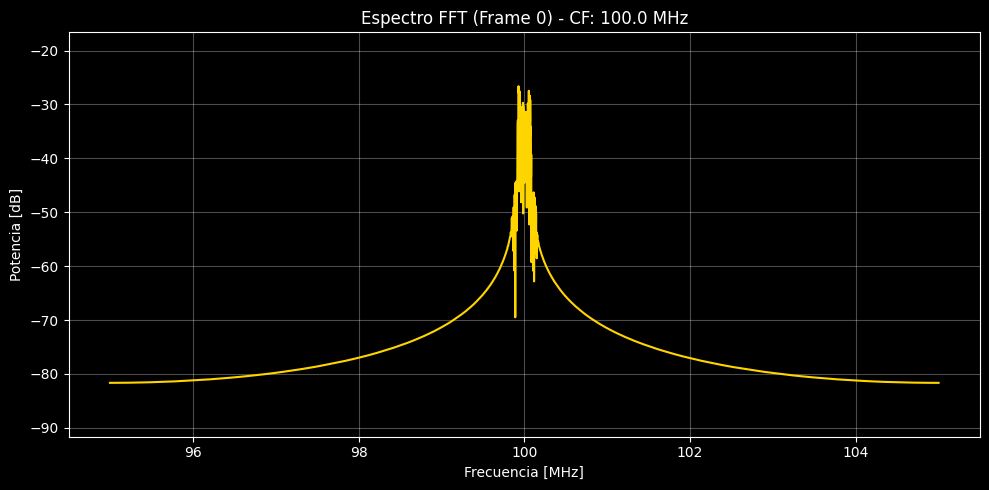

In [72]:
kernel=dsp.firwin(200,200e3/sr)
muestras_filt=np.convolve(muestras_iq,kernel,mode='same')

plot_fft(muestras_filt,cf,sr)

Nuevo sample rate 250.0 kHz


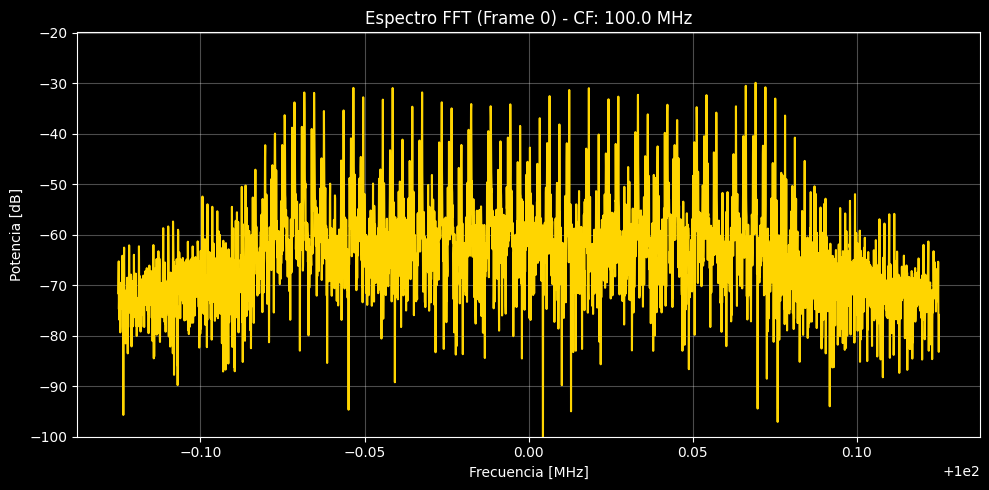

In [73]:
down_factor = int(sr/250e3) #40 si sr = 10MHz
muestras_resamp = dsp.resample_poly(muestras_filt, up=1, down=down_factor, window=('kaiser', 8.6))
sr_resamp=sr/down_factor

print("Nuevo sample rate",sr_resamp/1e3,"kHz")

plot_fft(muestras_resamp,cf,sr_resamp)

In [74]:
def FM_demod(señal,sr):
    return np.angle(señal[:-1]*np.conjugate(señal[1:]))*sr/(2*np.pi)



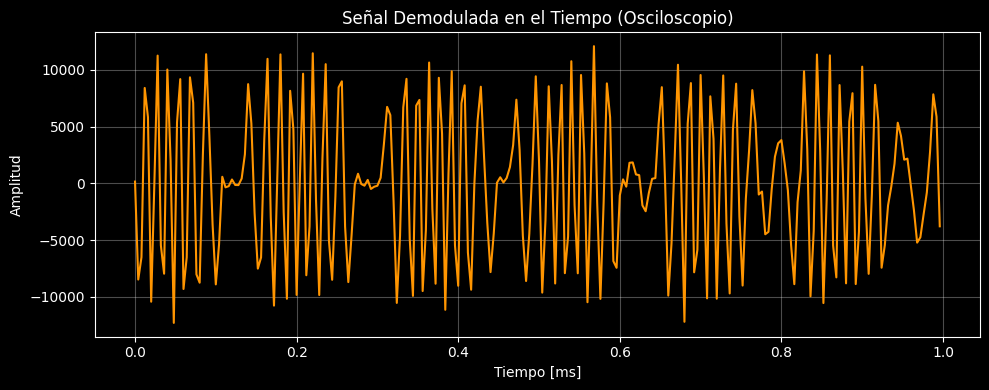

In [75]:
msj=FM_demod(muestras_resamp,sr_resamp)

t_audio = np.arange(len(msj)) / sr_resamp
tiempo_a_graficar = 0.001 
muestras_a_ver = int(sr_resamp * tiempo_a_graficar)

plt.figure(figsize=(10, 4))

# Multiplicamos el tiempo por 1000 para que el eje X quede lindo en milisegundos (ms)
plt.plot(t_audio[:muestras_a_ver] * 1000, msj[:muestras_a_ver], color='#FF9500', linewidth=1.5) 

plt.title("Señal Demodulada en el Tiempo (Osciloscopio)")
plt.xlabel("Tiempo [ms]")
plt.ylabel("Amplitud")
plt.grid(True, alpha=0.3)
plt.style.use('dark_background')
plt.tight_layout()
plt.show()